### Data Loading

In [79]:
import pandas as pd

data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(data_url , sep=";")

features = df.drop("quality",axis=1)
label = df["quality"].copy()

### Data Preperation

In [80]:
# Stratifing Data

from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(
    n_splits=1,
    random_state=42,
    test_size=0.2
)

for train_index , test_index in split.split(features,label):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

# Stratified Training DataSet
strat_wine_feat_train = strat_train_set.drop("quality" , axis=1)
strat_wine_label_train = strat_train_set["quality"].copy()

# Stratified Test DataSet
strat_wine_feat_test = strat_test_set.drop("quality" ,axis=1)
strat_wine_label_test = strat_test_set["quality"].copy()

# Transforming Data

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

transform_pipeline = Pipeline([
    ("Imputer" , SimpleImputer(strategy="median")),
    ("std_scaler" , StandardScaler())
])

wine_feat_tr_train = transform_pipeline.fit_transform(strat_wine_feat_train)
wine_feat_tr_test = transform_pipeline.transform(strat_wine_feat_test)


### Model Training

In [81]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(wine_feat_tr_train,strat_wine_label_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Model Performation

In [82]:
from sklearn.metrics import mean_squared_error

# Model Performation Onto Training DataSet
pred_train = lin_reg.predict(wine_feat_tr_train)
MSE_TRAIN = mean_squared_error(pred_train,strat_wine_label_train)
print(f"MSE In Training DataSet: {MSE_TRAIN}")

pred_test = lin_reg.predict(wine_feat_tr_test)
MSE_TEST = mean_squared_error(pred_test , strat_wine_label_test)
print(f"MSE In Test DataSet: {MSE_TEST}")


MSE In Training DataSet: 0.4206571060060278
MSE In Test DataSet: 0.40636065372564323


### Visualization

Text(0, 0.5, 'Predicted Quality')

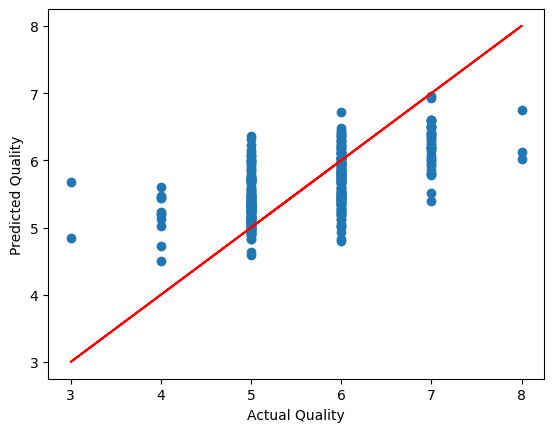

In [83]:
plt.scatter(strat_wine_label_test , pred_test)
plt.plot(strat_wine_label_test,strat_wine_label_test , 'r-')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")